In [9]:
import numpy as np
import matplotlib.pyplot as plt 

In [13]:
# Here we temporary use a package to read the format, later Ivan will re-format it to fits, which is easier to read
import pyANA as pyana

ImportError: /home/xenoss/miniconda3/envs/deepvel/lib/python3.10/lib-dynload/../../libssl.so.3: version `OPENSSL_3.2.0' not found (required by /home/xenoss/miniconda3/envs/deepvel/lib/python3.10/site-packages/tables/../../.././libcurl.so.4)

In [3]:
# Open a cube with specific spanshot number:
cube = pyana.fzread("/dat/milic/3D/3D_snapi_spectra/loc_dyn_32_32_16_0_tumag.f0")["data"]

# Note: all the data is in:
# /dat/milic/3D/3D_snapi_spectra/
# which should be accessible

NameError: name 'pyana' is not defined

In [ ]:
cube.shape
# Indices are x,y, stokes component, wavelength

(768, 768, 4, 622)

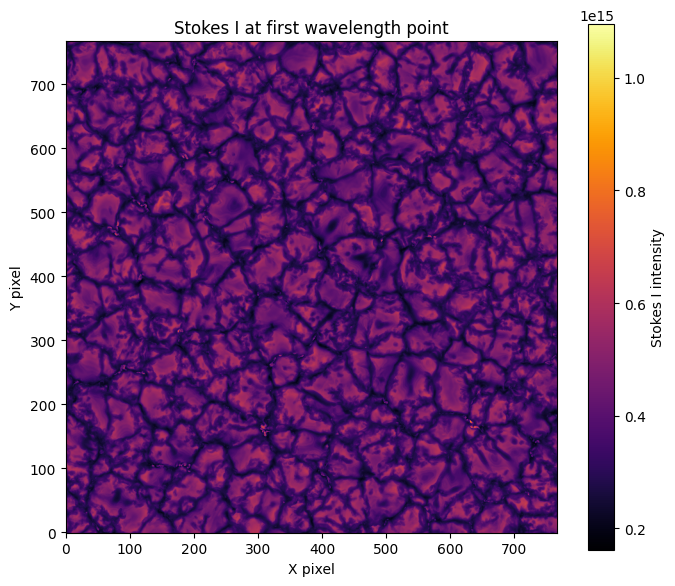

In [7]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(7,6))
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno')
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()

In [8]:
# As always we will normalize the units for the intensity to something we have a better physical intuition about.
# Usually, it is the mean intensity at the disk center. So: 
I_qs = np.mean(cube[:,:,0,:10])

In [9]:
cube /= I_qs  # Now the intensity is in units of quiet sun intensity

In [ ]:
# Now we want to make an image like the one up there, but with a slider that allows us to change the wavelength position interactively.
from ipywidgets import interact, IntSlider
@interact(wavelength_index=IntSlider(min=0, max=cube.shape[3]-1, step=1, value=0))
def plot_stokesI_at_wavelength(wavelength_index):
    plt.figure(figsize=(7,6))
    plt.imshow(cube[:,:,0,wavelength_index].T, origin='lower', cmap='inferno')
    plt.colorbar(label='Stokes I intensity (in units of I_qs)')
    plt.title(f'Stokes I at wavelength index {wavelength_index}')
    plt.xlabel('X pixel')
    plt.ylabel('Y pixel')
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='wavelength_index', max=621), Output()), _dom_classes=('w…

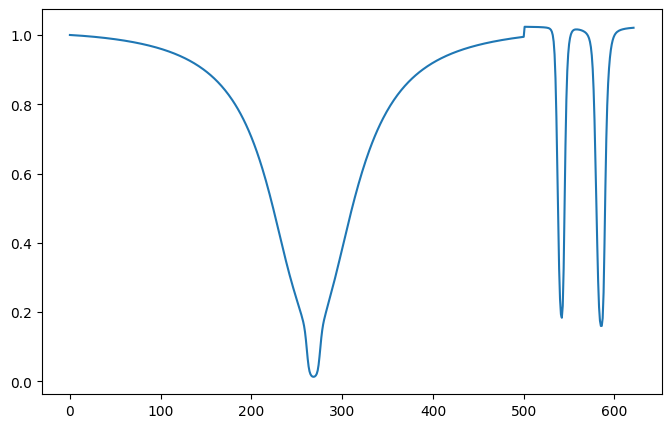

In [11]:
# to find interesting wavelength positions, we can plot the average spectrum over the whole cube:
mean_spectrum = np.mean(cube[:,:,0,:], axis=(0,1))
plt.figure(figsize=(8,5))
plt.plot(mean_spectrum)

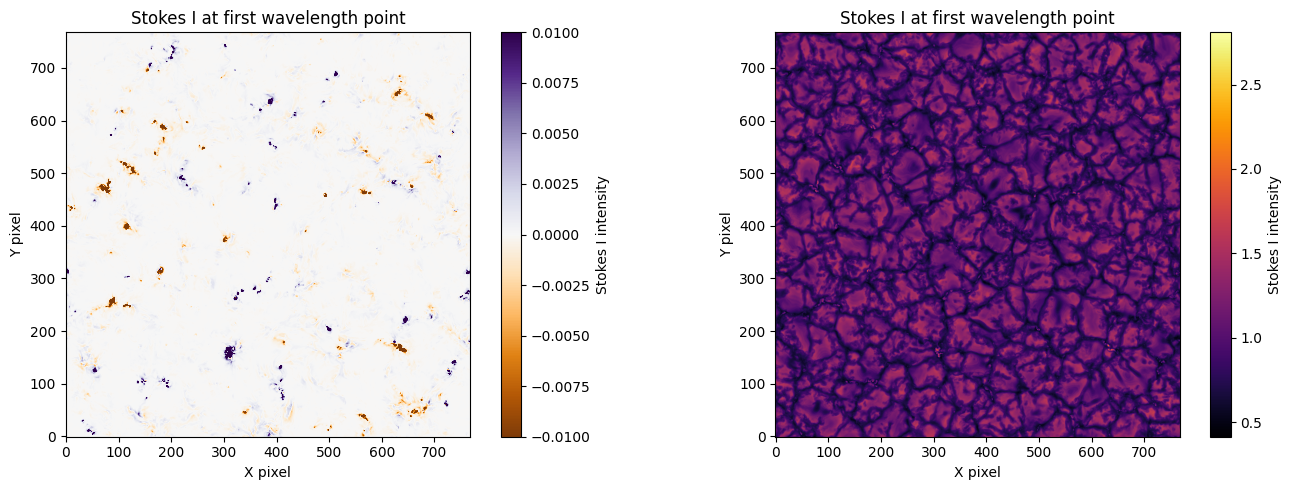

In [31]:
# Plot image at a specific wavelength: 
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
#plt.imshow(cube[:,:,3,265].T, origin='lower', cmap='inferno',vmin=0.0,vmax=0.3)
plt.imshow(cube[:,:,3,265].T, origin='lower', cmap='PuOr',vmin=-0.01,vmax=0.01)
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.subplot(1,2,2)
plt.imshow(cube[:,:,0,0].T, origin='lower', cmap='inferno')
plt.colorbar(label='Stokes I intensity')
plt.title('Stokes I at first wavelength point')
plt.xlabel('X pixel')
plt.ylabel('Y pixel')
plt.tight_layout()

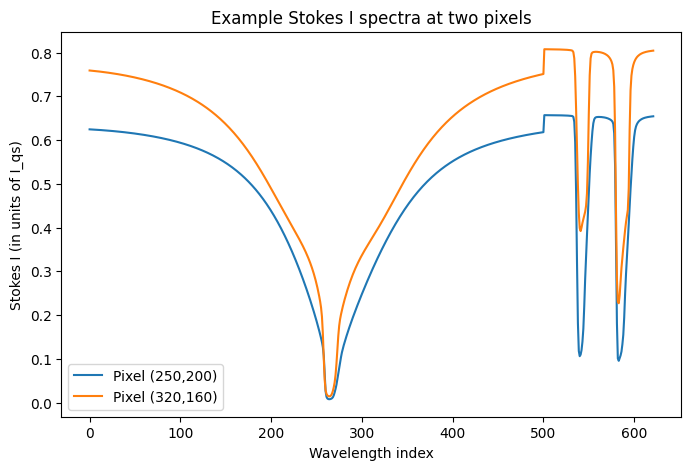

In [26]:
# Let's plot two example spectra:
plt.figure(figsize=(8,5))
plt.plot(cube[250,200,0,:], label='Pixel (250,200)')
plt.plot(cube[320,160,0,:], label='Pixel (320,160)')
plt.xlabel('Wavelength index')
plt.ylabel('Stokes I (in units of I_qs)')
plt.title('Example Stokes I spectra at two pixels')
plt.legend()

In [34]:
# Disregard this, this was just to create fits files, in principle they will all be fits.
from astropy.io import fits
hdu = fits.PrimaryHDU(cube[:,:,[0,3],:])  # Save only Stokes I
hdu.writeto('/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_0.fits', overwrite=True)

In [14]:
# So for the moment, we are only working with Stokes I 

# Once all the cubes are converted to fits, we can read them with astropy.io.fits
from astropy.io import fits

In [15]:
cube = fits.open("/dat/milic/3D/3D_snapi_spectra/tumag_stokesIV_cube_0.fits")[0].data

In [ ]:
cube.shape # (x,y,stokesIV,wavelength)

(768, 768, 2, 622)